# minGRU (Feng et al., 2024) with the associative scan
## This code uses `heinsen` associative scan instead of flax.linen.scan to further optimize the code


## Equations
State update:

$
\vec{z}_t = \sigma(W^{z}\vec{x}_t) \\
\vec{\~h}_t = W^{h}\vec{x}_t \\
\vec{h}_t = (1 - \vec{z}_t) \odot \vec{h}_{t-1} + \vec{z}_t \odot \vec{\~h}_t \\
$

Output: mean of output over time (or cummulative sum of output over time):

$
\vec{o}_t = W^{oh}\vec{h}_t + \vec{b}^o \\
\vec{o} = \frac{1}{T}\sum_{t=1}^{T}\vec{o}_t \\
\vec{y} = \text{softmax}(\vec{o}) \\
$

## Heinsen Associative Scan

$
\vec{h}_t = (1 - \vec{z}_t) \odot \vec{h}_{t-1} + \vec{z}_t \odot \vec{\~h}_t \\
$

Can be rewritten as:

$
\vec{h}_t = \vec{a}_t \odot \vec{h}_{t-1} + \vec{b}_t \text{ where } 
\vec{a}_t = 1 - \vec{z}_t \text{ and }
\vec{b}_t = \vec{z}_t \odot \vec{\~h}_t 
$

This can be speed up by using the formula:
$ \overrightarrow{h}_t = (\prod_{n=1}^{t,cum} a_n) \odot (x_0 + \sum_{n=1}^{t,cum} \frac{b_n}{\prod_{n=1}^{t} a_n}) $

However, this formula is numerically unstable because of the product of a large number of small values. To avoid this, we can use the log-sum-exp trick:

$ log(\overrightarrow{h}_t) = log(\prod_{n=1}^{t,cum} a_n) + log(x_0 + \sum_{n=1}^{t,cum} \frac{b_n}{\prod_{n=1}^{t} a_n}) $

$ log(\overrightarrow{h}_t) = \sum_{n=1}^{t,cum} log(a_n) + log(x_0 + \sum_{n=1}^{t,cum} \frac{b_n}{\prod_{n=1}^{t} a_n}) $



In [1]:
!pwd
!which python
!pip freeze | grep -E 'flax|jax|orbax|optax'

/home/tristan/Den-minGRU/main
/home/tristan/miniconda3/envs/.jax_conda_env_Den-minGRU/bin/python
flax==0.8.0
jax==0.4.25
jaxlib==0.4.25+cuda11.cudnn86
optax==0.1.8
orbax-checkpoint==0.5.0


In [2]:
# set up the notebook autoreload
%load_ext autoreload
%autoreload 2

In [3]:
import jax
import numpy as np
import torch
from jax import numpy as jnp
from flax import linen as nn
from flax.training import train_state, checkpoints
import optax
import matplotlib.pyplot as plt
px = 1 / plt.rcParams['figure.dpi']

jnp.set_printoptions(precision=3, suppress=True)

# set cuda visible devices
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"
# set jax XLA_PYTHON_CLIENT_MEM_FRACTION=.XX
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = ".50"

SEED = 0
# fix random seed
key = jax.random.PRNGKey(SEED)
torch.manual_seed(SEED)
np.random.seed(SEED)

DATASET_VERSION = 'mnist'
BATCH_SIZE = 64
N_LAYERS = 3
HIDDEN_DIM = [50]*N_LAYERS
hidden_dim_str = HIDDEN_DIM[0]
LATENT_DIM = [None]*N_LAYERS
latent_dim_str = LATENT_DIM[0] if LATENT_DIM[0] is not None else 'F'
# HIDDEN_DIM = [2, 3, 4, 6, 7, 5]
# LATENT_DIM = [2, 3, 4, 6, 7, 5]
# hidden_dim_str = ''
# latent_dim_str = ''
# for h in HIDDEN_DIM:
#     hidden_dim_str += str(h) + '-'
#     latent_dim_str += str(l) + '-'
DELAY_TYPE = 'synaptic' # 'synaptic', 'axonal' (later: 'dendritic')
DELAY_KERNEL = 'gaussian' # 'gaussian', (later: 'exponential')
LAYER_ACT = 'linear' # 'relu', 'tanh', 'sigmoid', 'linear'
N_EPOCHS = 50
LR = 1e-3
DO_RATE = 0

assert len(HIDDEN_DIM) == len(LATENT_DIM) == N_LAYERS, "Hidden and latent dimensions must match the number of layers"



In [4]:
# !pip3 install tqdm
# !pip3 install msgpack
# !pip3 install absl-py
# !pip3 install rich
# !pip3 install chex
# !pip3 install etils
# !pip3 install importlib_resources
# !pip3 install tensorstore
# !pip3 install --upgrade google-api-python-client
# !pip3 install matplotlib
# !pip3 install plotly
# !pip3 install scikit-learn
# !pip3 install pandas

In [5]:
from utils import create_mnist_classification_dataset, create_cifar_gs_classification_dataset

In [6]:
key, subkey = jax.random.split(key)
if DATASET_VERSION == 'cifar':
    trainloader, val_loader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM = create_cifar_gs_classification_dataset(bsz=BATCH_SIZE, root="data")
else:
    trainloader, val_loader, testloader, N_CLASSES, SEQ_LENGTH, IN_DIM = create_mnist_classification_dataset(bsz=BATCH_SIZE, root="data")

[*] Generating MNIST Classification Dataset...


In [7]:
batch_x, batch_y = next(iter(testloader))
print(batch_x.shape, batch_y.shape)
print(batch_y.dtype)

(64, 784, 1) (64,)
int64


# Multi Layer (3 hidden, 1 output) 
## This code uses flax.linen.scan to speed up the loop over time

## Equations
The output of a LSTM layer is $

In [8]:
from model import BatchRNN_Delayed, minGRULayer
from training import create_train_state
from functools import partial

In [9]:
model_cls = partial(
    BatchRNN_Delayed, fft=False, delay_type=DELAY_TYPE, delay_kernel=DELAY_KERNEL,
    n_layers=N_LAYERS, out_dim=N_CLASSES, hidden_dim=tuple(HIDDEN_DIM),
    latent_dim=tuple(LATENT_DIM), layer_act=LAYER_ACT, do_rate=DO_RATE)
                    
# model_mingru = BatchRNN(HIDDEN_DIM, 10, N_LAYERS, recurrent_layer=minGRULayer)
sim_args = {'key':key, 'model_cls': model_cls, 'lr':LR, 'dataset_version':'sequential', 'seq_len': SEQ_LENGTH, 'batch_size':BATCH_SIZE}
state, n_params, p_init = create_train_state(**sim_args)

Initialized parameter structure: {'DCLSLayer_0': {'positions': (1, 1), 'std': (1, 1), 'weights': (1, 1)}, 'DCLSLayer_1': {'positions': (50, 50), 'std': (50, 50), 'weights': (50, 50)}, 'DCLSLayer_2': {'positions': (50, 50), 'std': (50, 50), 'weights': (50, 50)}, 'Dense_Out': {'bias': (10,), 'kernel': (50, 10)}, 'HeinsenMinGRULayerOriginal_0': {'Dense_x': {'bias': (100,), 'kernel': (1, 100)}}, 'HeinsenMinGRULayerOriginal_1': {'Dense_x': {'bias': (100,), 'kernel': (50, 100)}}, 'HeinsenMinGRULayerOriginal_2': {'Dense_x': {'bias': (100,), 'kernel': (50, 100)}}}
[*] Trainable Parameters: 25913


In [10]:
jnp.set_printoptions(linewidth=1000)
key = jax.random.PRNGKey(0)
key, key1, key2 = jax.random.split(key, 3)
model_tab = model_cls(training=False)
tabulate_fn = nn.tabulate(model_tab, {'params': key1, 'dropout': key2})
print(tabulate_fn(batch_x))


                        VmapRNN_Delayed_Backbone Summary                        
┏━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ path          ┃ module        ┃ inputs        ┃ outputs       ┃ params       ┃
┡━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│               │ VmapRNN_Dela… │ int32[]       │ int32[]       │              │
├───────────────┼───────────────┼───────────────┼───────────────┼──────────────┤
│ DCLSLayer_0   │ DCLSLayer     │ float32[784,… │ float32[735,… │ positions:   │
│               │               │               │               │ float32[1,1] │
│               │               │               │               │ std:         │
│               │               │               │               │ float32[1,1] │
│               │               │               │               │ weights:     │
│               │               │               │               │ float32[1,1] │
│               │          

In [11]:
# params = model.init(jax.random.PRNGKey(0), jnp.zeros_like(batch_x[:BATCH_SIZE]))
# params_mingru = model_mingru.init(jax.random.PRNGKey(0), jnp.zeros_like(batch_x[:BATCH_SIZE]))

In [12]:
# print(jax.tree_util.tree_map(jnp.shape, params['params']))
# print(jax.tree_util.tree_map(jnp.shape, params_mingru['params']))

In [13]:
# plot_dynamics(model, state.params, batch_x, batch_y, dataset_version='sequential', 
#               id_sample=0, model_type='mingru_heinsen', variable_to_plot='z')

In [14]:
from training import run_epoch, validate

In [15]:
reg_factor = 0 # 1e-6, 1e-7, 1e-8, 0.0
id_sim = f"mingru_dcls/h{hidden_dim_str}_l{N_LAYERS}_lr{LR}_bsz{BATCH_SIZE}_Hpreact_reg{reg_factor}_lat{latent_dim_str}_la{LAYER_ACT}_do{DO_RATE}_{DELAY_TYPE}{DELAY_KERNEL}_s{SEED}"
CKPT_DIR = os.path.join(os.getcwd(), f"checkpoints/{id_sim}")
if os.path.exists(CKPT_DIR):
    id_sim += f"_training_1"
i = 2
while os.path.exists(CKPT_DIR):
    # pop the last number from the id_sim
    id_sim = id_sim[:-1]
    id_sim += f"{i}"
    CKPT_DIR = os.path.join(os.getcwd(), f"checkpoints/{id_sim}")
    i += 1
print(CKPT_DIR)
print(CKPT_DIR)
RESULT_DIR = os.path.join(os.getcwd(), f"results/{id_sim}")
print(RESULT_DIR)
os.makedirs(RESULT_DIR, exist_ok=True)
PLT_DIR = os.path.join(os.getcwd(), f"plots/{id_sim}")
print(PLT_DIR)
os.makedirs(PLT_DIR, exist_ok=True)


train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []
test_losses = []
test_accuracies = []
# 'batch_loss' = [loss_sample1, loss_sample2, ..., loss_sampleBS]
# 'loss' = [loss_batch1, loss_batch2, ..., loss_batchN] where N is the number of batches and loss_batchX = mean([loss_sample1, loss_sample2, ..., loss_sampleBS])
keys_to_track = [] #['grads', 'loss', 'state', 'batch_x', 'batch_y'] # ['batch_x', 'batch_y', 'state', 'grads']
inner_keys_to_track = [] #['batch_loss', 'net_dyn']
aux_dict_training = []

best_val_acc = 0.0
improvement = 0.01 # 1%, minimum improvement to save checkpoint

async_manager = checkpoints.AsyncManager()
test_loss = 2.5
test_acc = 0.0
for epoch in range(N_EPOCHS):
    key, subkey = jax.random.split(key) # not used in run_epoch (TODO: remove?)
    state, train_loss, train_acc, (break_flag, aux_dict_epoch) = run_epoch(state, model_cls, trainloader, subkey, reg_factor=reg_factor, lim_batch=None, keys_to_track=keys_to_track, inner_keys_to_track=inner_keys_to_track)
    aux_dict_training.append(aux_dict_epoch)
    if break_flag:
        break
    val_loss, val_acc  = validate(state, model_cls, val_loader)
    if val_acc > best_val_acc + improvement:
        best_val_acc = val_acc
        if best_val_acc > 0.94: improvement = 0.001 # 0.1%
        test_loss, test_acc = validate(state, model_cls, testloader)
        checkpoints.save_checkpoint(ckpt_dir=CKPT_DIR, target=state, step=state.step, overwrite=True, async_manager=async_manager)
        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_acc*100:.2f}% | val_loss: {val_loss:.4f} | val_acc: {val_acc*100:.2f}% | test_loss: {test_loss:.4f} | test_acc: {test_acc*100:.2f}%")
    else: 
        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | train_acc: {train_acc*100:.2f}% | val_loss: {val_loss:.4f} | val_acc: {val_acc*100:.2f}%")

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

# Save training dynamics
np.savez(os.path.join(RESULT_DIR, 'training_dynamics.npz'), 
         train_losses=train_losses, 
         train_accuracies=train_accuracies, 
         val_losses=val_losses, 
         val_accuracies=val_accuracies,
         test_losses=test_losses,
         test_accuracies=test_accuracies)

/home/tristan/Den-minGRU/main/checkpoints/mingru_dcls/h50_l3_lr0.001_bsz64_Hpreact_reg0_latF_lalinear_do0_synapticgaussian_s0
/home/tristan/Den-minGRU/main/checkpoints/mingru_dcls/h50_l3_lr0.001_bsz64_Hpreact_reg0_latF_lalinear_do0_synapticgaussian_s0
/home/tristan/Den-minGRU/main/results/mingru_dcls/h50_l3_lr0.001_bsz64_Hpreact_reg0_latF_lalinear_do0_synapticgaussian_s0
/home/tristan/Den-minGRU/main/plots/mingru_dcls/h50_l3_lr0.001_bsz64_Hpreact_reg0_latF_lalinear_do0_synapticgaussian_s0


Training: 100%|██████████| 781/781 [00:16<00:00, 47.13it/s, accuracy=0.734, loss=0.76] 


Epoch 0 | train_loss: 1.6349 | train_acc: 53.82% | val_loss: 0.8774 | val_acc: 72.03% | test_loss: 0.8933 | test_acc: 71.07%


Training: 100%|██████████| 781/781 [00:08<00:00, 95.35it/s, accuracy=0.859, loss=0.596]


KeyboardInterrupt: 

In [18]:
from model import construct_kernel_fast

In [21]:
def get_kernels(params, name, n_dim):
    ks = []
    for i in range(N_LAYERS):
        w = params[f'{name}_{i}']['weights']
        p = params[f'{name}_{i}']['positions']
        s = params[f'{name}_{i}']['std']
        k = construct_kernel_fast(w, p, s, 50, n_dim)
        ks.append(k)
    return ks


In [22]:
ks_init = get_kernels(p_init, f'DCLSLayer', 2) # DCLSLayer_Axonal
ks = get_kernels(state.params, f'DCLSLayer', 2) # DCLSLayer_Axonal


In [23]:
def plot_kernels_axonal(ks):
    PX = 1 / plt.rcParams['figure.dpi']
    fig, axes = plt.subplots(N_LAYERS, 1, figsize=(1000*PX, 200 * PX * N_LAYERS), constrained_layout=True)

    for i in range(N_LAYERS):
        max_val = np.max(np.abs(ks[i]))
        ax = axes[i] if N_LAYERS > 1 else axes  # Handle single subplot case
        im = ax.matshow(ks[i], cmap='RdBu_r', vmin=-max_val, vmax=max_val)
        ax.set_title(f"Visualization of ks[{i}]")
        ax.set_yticks(np.arange(ks[i].shape[0]))

    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    plt.show()


In [24]:
def plot_kernels_syn(ks):
    PX = 1 / plt.rcParams['figure.dpi']
    fig, axes = plt.subplots(1, N_LAYERS, figsize=(1000*PX, 1500 * PX * N_LAYERS), constrained_layout=True)

    for i in range(N_LAYERS):
        max_val = np.max(np.abs(ks[i]))
        ax = axes[i] if N_LAYERS > 1 else axes  # Handle single subplot case
        im = ax.matshow(ks[i].reshape(ks[i].shape[0]*ks[i].shape[1], ks[i].shape[2]), cmap='RdBu_r', vmin=-max_val, vmax=max_val)
        ax.set_title(f"Visualization of ks[{i}]")
        yticks_labels = np.arange(ks[i].shape[0]).repeat(ks[i].shape[1])
        ax.set_yticks(np.arange(0, ks[i].shape[0]*ks[i].shape[1], 1))
        ax.set_yticklabels(yticks_labels)

    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    plt.show()


In [25]:
jnp.arange(10).repeat(2)

Array([0, 0, 1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9], dtype=int32)

IndexError: tuple index out of range

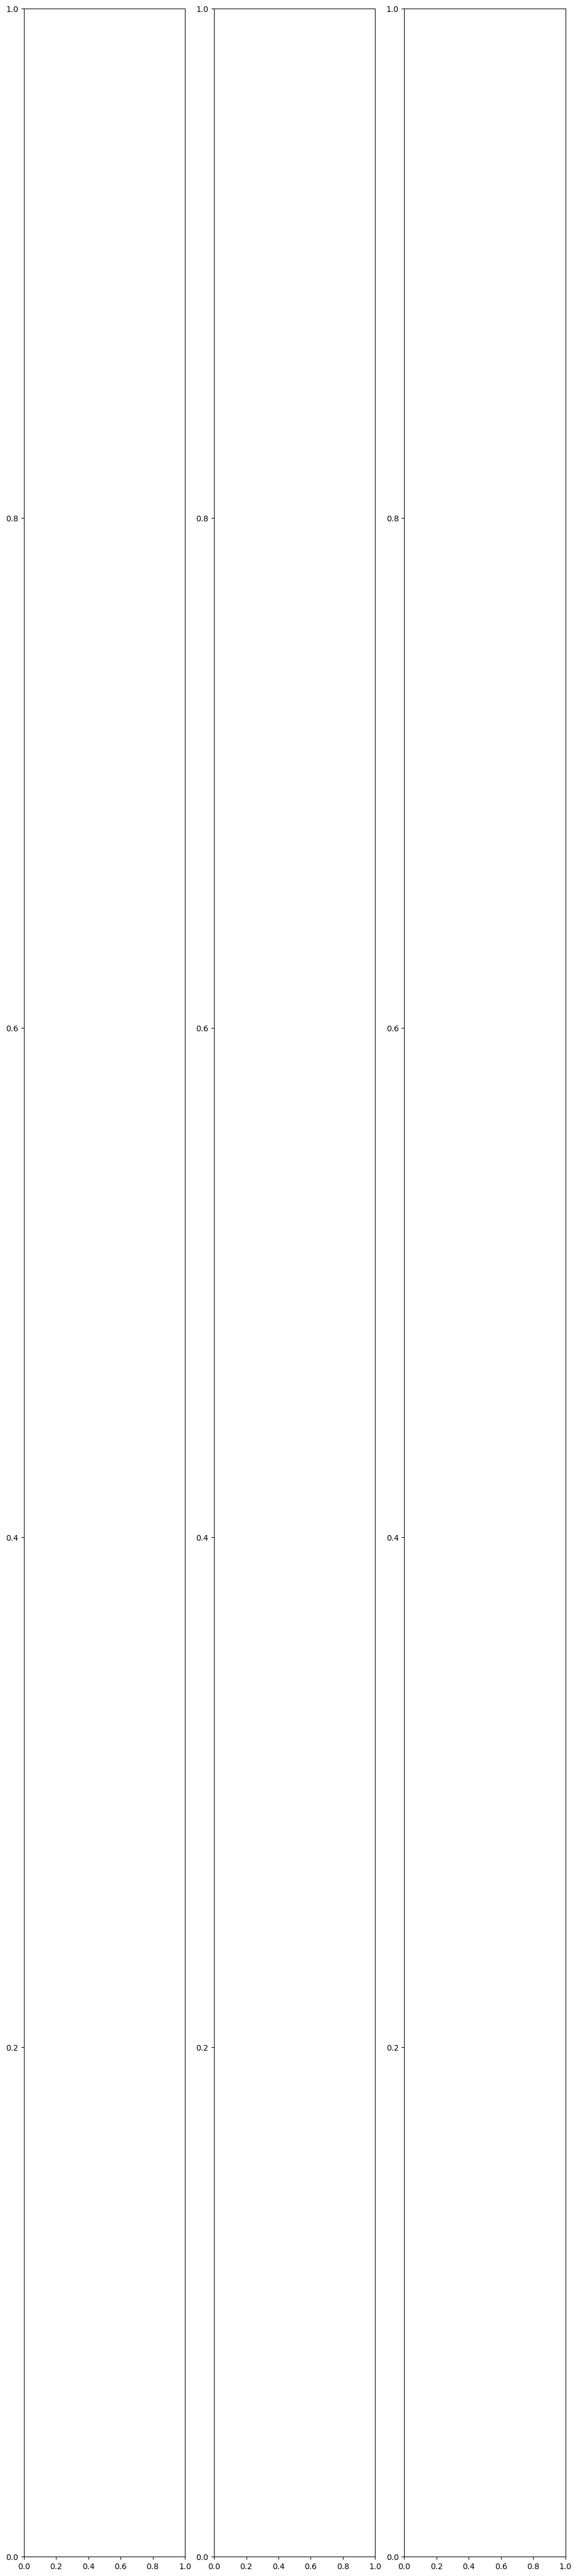

In [26]:
plot_kernels_syn(ks_init)

IndexError: tuple index out of range

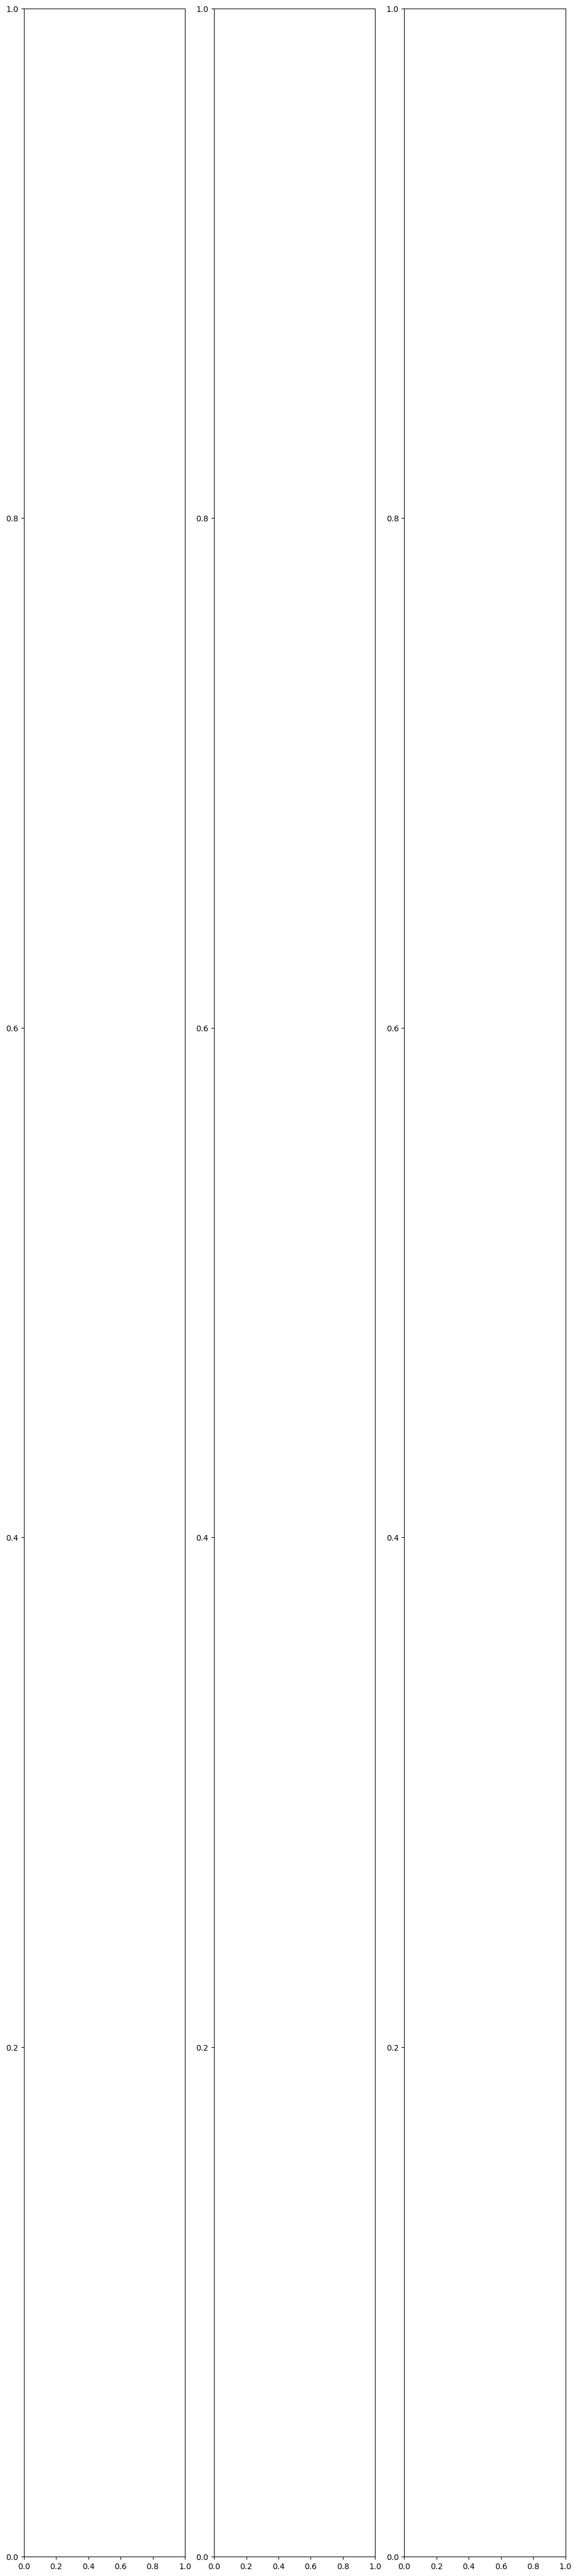

In [27]:
plot_kernels_syn(ks)

In [40]:
def plot_kernels(ks):
    PX = 1 / plt.rcParams['figure.dpi']
    fig, axes = plt.subplots(N_LAYERS, 1, figsize=(300*PX, 300 * PX * N_LAYERS))

    for i in range(N_LAYERS):
        max_val = np.max(np.abs(ks[i]))
        ax = axes[i] if N_LAYERS > 1 else axes  # Handle single subplot case
        im = ax.matshow(ks[i], cmap='RdBu_r', vmin=-max_val, vmax=max_val)
        ax.set_title(f"Visualization of ks[{i}]")
        ax.set_yticks(np.arange(ks[i].shape[0]))

    fig.colorbar(im, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2206849/959721218.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


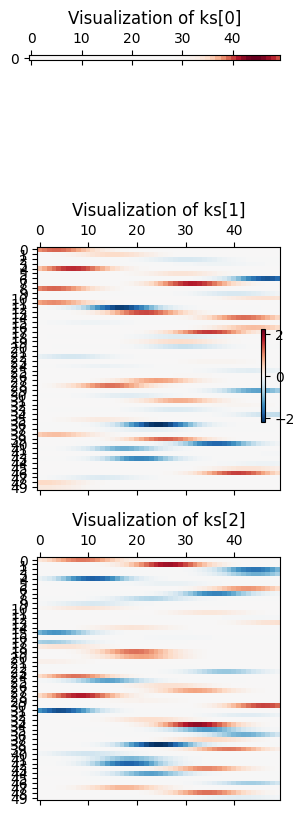

In [41]:
plot_kernels(ks_init)

/tmp/ipykernel_2206849/959721218.py:13: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


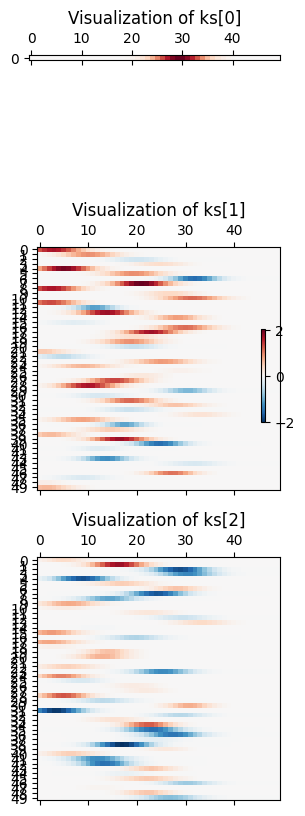

In [42]:
plot_kernels(ks)

ValueError: zero-size array to reduction operation minimum which has no identity

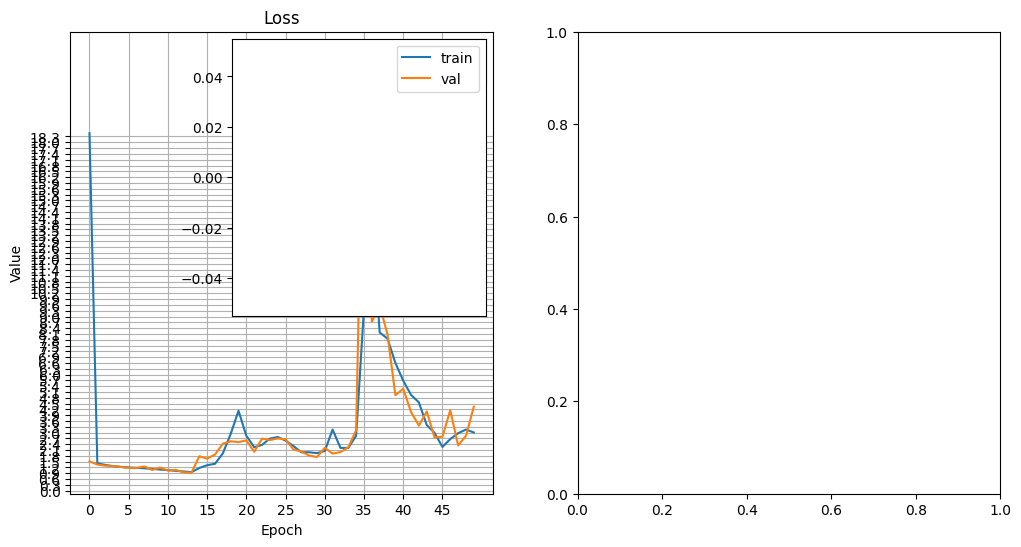

In [43]:
from plots import plot_loss_and_acc
plot_loss_and_acc(train_losses, val_losses, train_accuracies, val_accuracies)

In [ ]:
from plots import plot_digits
digit_to_plot = 1
plot_digits(digit_to_plot, model, state.params, 'mingru_heinsen', 
            batch_x, batch_y, PLT_DIR, variable_to_plot='z',
            layer_to_plot=2, nb_components_to_plot=10)

In [ ]:
from utils import plot_all_digits
plot_all_digits(model, state.params, 'mingru_heinsen', batch_x, batch_y, plt_dir=PLT_DIR, 
                nb_components_to_plot=10, layer_to_plot=1, variable_to_plot='o')


In [20]:
# how to write to a txt file
grads_hist = aux_dict_training[-1]['grads']
step_loss = aux_dict_training[-1]['loss']
with open('flax4b_minGRU_heinsen_grads.txt', 'w') as f:
    for i in range(len(aux_dict_training[-1]['grads'])):
        str_ = f'{jax.tree_util.tree_map(lambda x: round(float(jnp.max(jnp.abs(x))),2), grads_hist[i])}, {step_loss[i]}\n'
        f.write(str_)

KeyError: 'grads'

In [17]:
bad_state = aux_dict_training[-1]['state'][-2]
state_hist, out_hist = bad_state.apply_fn({'params': bad_state.params}, batch_x)
print(len(state_hist))
print(len(state_hist[0]))

KeyError: 'state'

4
3
(5, 784, 10)


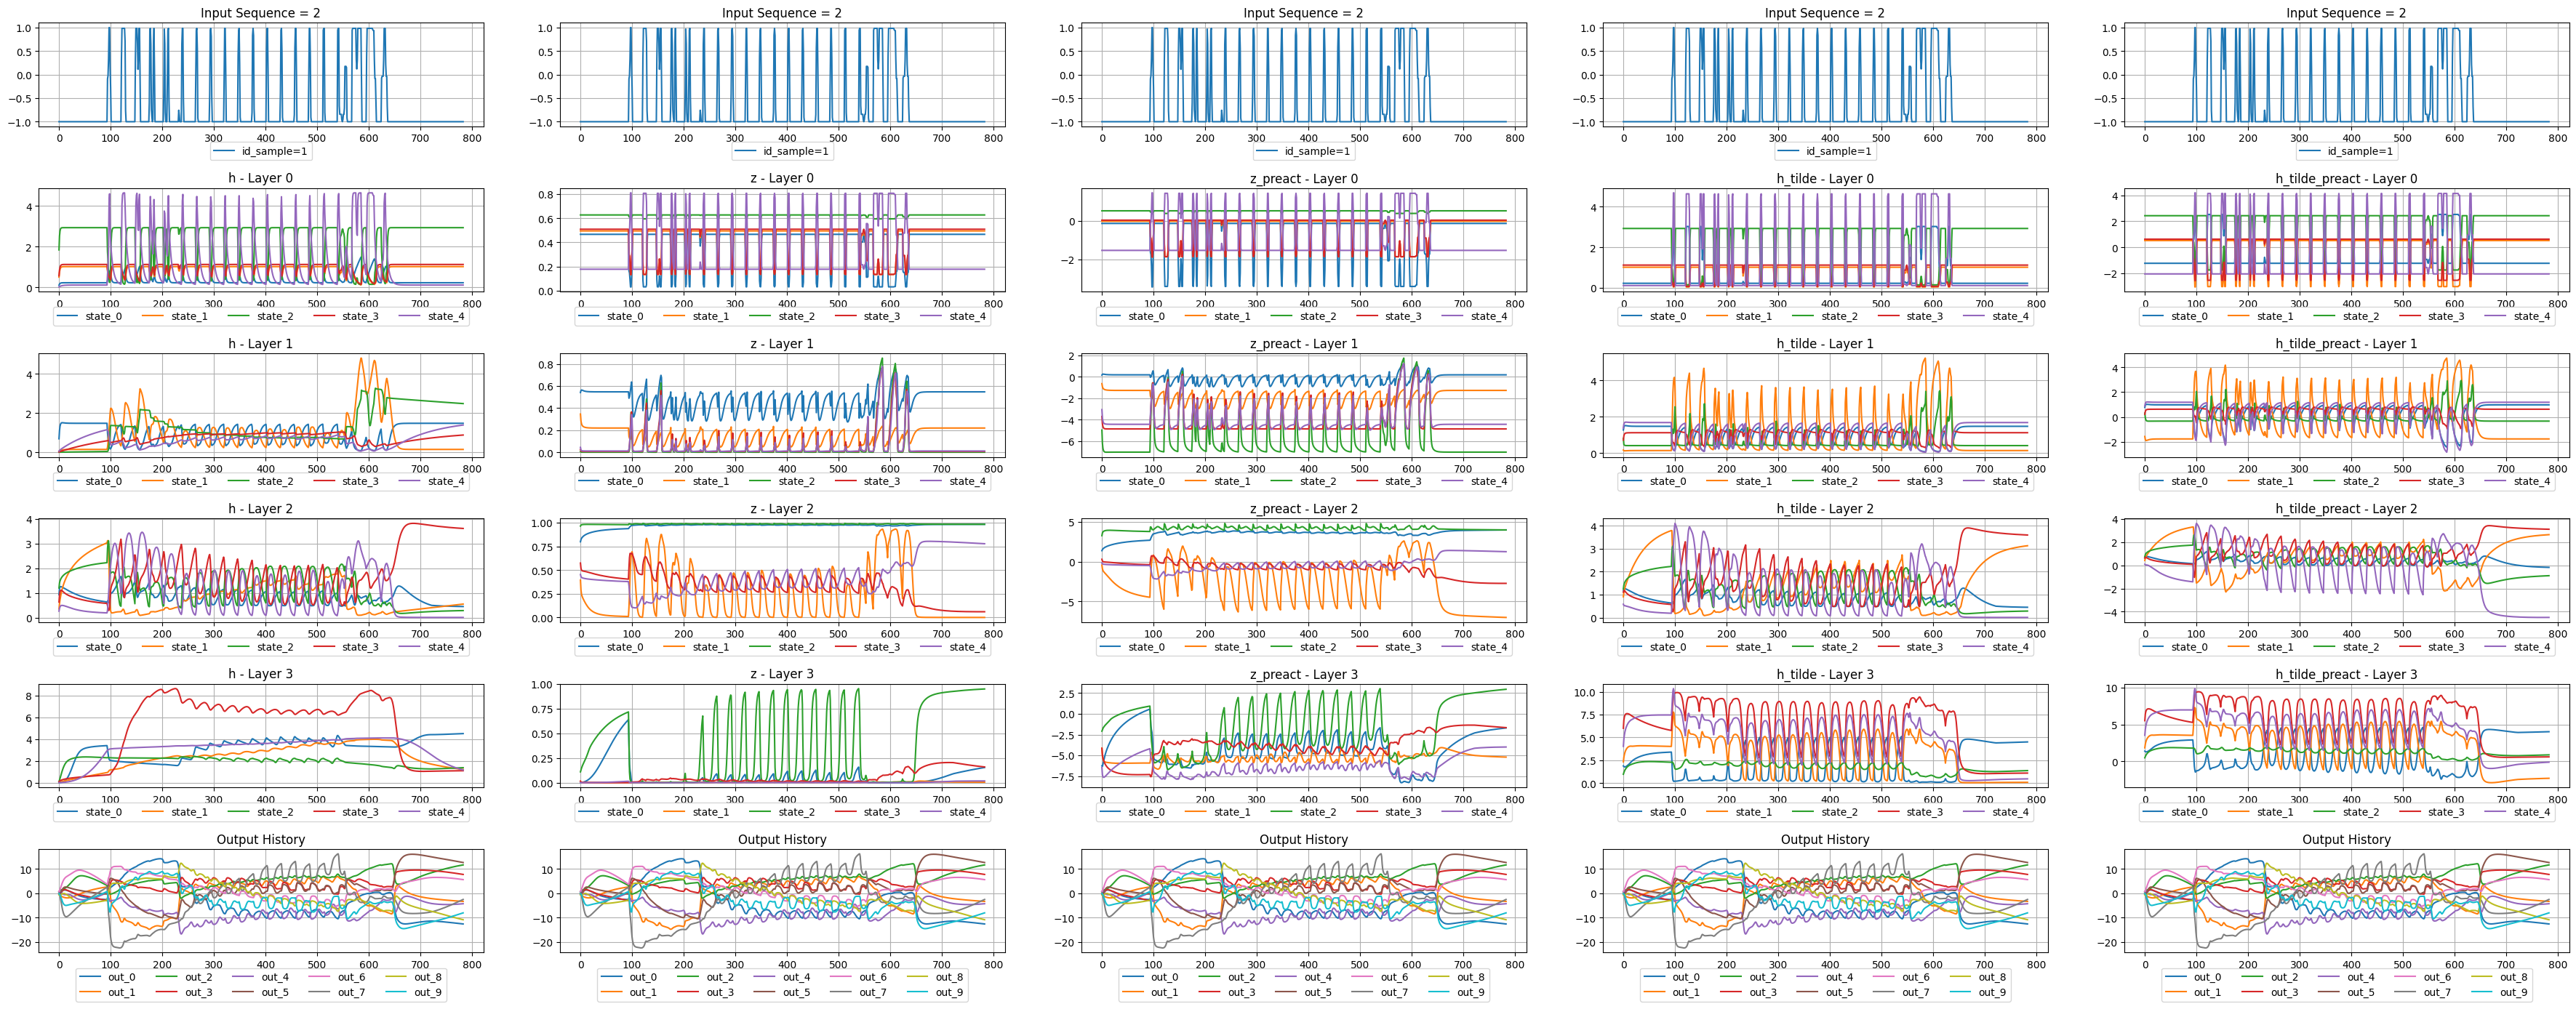

In [19]:
plot_dynamics(model, state.params, batch_x, batch_y, dataset_version=DATASET_VERSION, 
              id_sample=1, model_type='mingru_heinsen', variable_to_plot='all', nb_components_to_plot=5, zoom=False)

print(len(aux))